# Analysis of the ParlaMint-SI corpus: utterance-level annotations (best-performing heuristic)
Analysis of the sentiment trends at the utterance level using the best-performing heuristic: a character-based average of sentence-level sentiment score


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../../Datasets/Sentiment_Analysis/ParlaMint-SI.tsv', delimiter='\t', encoding='utf-8')
df = df.drop_duplicates(subset=['ID']).reset_index(drop=True)

df.head()

,ID,sent_id,text,text_en,sent_annotations,utt_annotations,labels,sentiment,h_annotations,h_labels,...,Speaker_MP,Speaker_minister,Speaker_party,Speaker_party_name,Party_status,Party_orientation,Speaker_ID,Speaker_name,Speaker_gender,Speaker_birth
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Spoštovane kolegice poslanke in kolegi poslanc...,"Dear fellow Members and fellow Members, ladies...",4.052144,2.42,Neutral Negative,Neutral,2.401479,Neutral Negative,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Spoštovane kolegice in kolegi, gospe in gospodje!","Dear colleagues, ladies and gentlemen!",3.846659,3.88,Mixed Positive,Positive,2.805297,Neutral Positive,...,MP,notMinister,NP,Poslanska skupina nepovezanih poslancev,-,-,ZorčičIgor,"Zorčič, Igor",M,1978
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Hvala tudi vam.,"Thank you, too.",4.758979,3.00,Neutral Positive,Neutral,3.365201,Neutral Positive,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Hvala lepa, predsedujoči.","Thank you very much, Chairman.",4.019485,3.19,Neutral Positive,Neutral,3.148236,Neutral Positive,...,notMP,notMinister,-,-,-,-,SlavinecMitja,"Slavinec, Mitja",M,1964
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u5,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Hvala tudi vam.,"Thank you, too.",4.758979,3.00,Neutral Positive,Neutral,3.271888,Neutral Positive,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953


In [2]:
check_min = df['h_annotations'].min()
check_max = df['h_annotations'].max()
print("Lowest h-annotation value: ", check_min)
print("Highest h-annotation value: ", check_max)

Lowest h-annotation value:  -0.10373181849718
Highest h-annotation value:  5.452958583831787


In [3]:
# Renaming slv metadata to eng (X. mandat -> Term X)
df['Term'] = df['Term'].replace({
    '3. mandat': 'Term 3',
    '4. mandat': 'Term 4',
    '5. mandat': 'Term 5',
    '6. mandat': 'Term 6',
    '7. mandat': 'Term 7',
    '8. mandat': 'Term 8'
})
df['Year'] = df['Date'].str.split('-').str[0]

term6 = df[df['Year'] == '2012']
update_term6 = term6.index
df.loc[update_term6, 'Term'] = 'Term 6'

term5_check = df[df['Term'] == 'Term 5']
print("Earliest Term5 speech: ", term5_check['Date'].min())
print("Last Term5 speech: ", term5_check['Date'].max())

term6_check = df[df['Term'] == 'Term 6']
print("Earliest Term6 speech: ", term6_check['Date'].min())
print("Last Term6 speech: ", term6_check['Date'].max())

term7 = df[(df['Date'] == '2018-10-11') & (df['ID'].str.contains('ParlaMint-SI_2018-10-11-SDZ7-Izredna-49.ana'))]
update_term7 = term7.index
df.loc[update_term7, 'Term'] = 'Term 8'

term7_check = df[df['Term'] == 'Term 7']
print("Earliest Term7 speech: ", term7_check['Date'].min())
print("Last Term7 speech: ", term7_check['Date'].max())

term8_check = df[df['Term'] == 'Term 8']
print("Earliest Term8 speech: ", term8_check['Date'].min())
print("Last Term8 speech: ", term8_check['Date'].max())


Earliest Term5 speech:  2008-10-15
Last Term5 speech:  2011-12-08
Earliest Term6 speech:  2011-12-21
Last Term6 speech:  2014-07-04
Earliest Term7 speech:  2014-08-01
Last Term7 speech:  2018-05-24
Earliest Term8 speech:  2018-06-22
Last Term8 speech:  2022-04-06


## Descriptive statistics

Checking (sentiment) distributions within the new ParlaMint-SI corpus based of the best-performing heuristic sentiment annotations.


In [5]:
check_labels = df['h_labels'].value_counts()
check_sentiment = df['h_sentiment'].value_counts()

print(check_labels)
print(check_sentiment)

h_labels
Neutral Positive    156602
Neutral Negative     70730
Mixed Positive       44383
Mixed Negative       36488
Negative              2663
Positive               481
Name: count, dtype: int64
h_sentiment
Neutral     227332
Positive     44864
Negative     39151
Name: count, dtype: int64


## Removing procedural speeches
Checking the percentage of procedural speeches in the corpus, removing them and checking ```h_labels``` and ```h_sentiment```distributions again.

In [9]:
#Checking percentage of procedural speeches

df_procedural = df[df['Speaker_role'] != 'Regular']
percent_procedural = (len(df_procedural) / len(df)) * 100

print("Total no. of speeches: ", len(df))
print("Total no. of procedural speeches: ", len(df_procedural), "%: ", percent_procedural)

Total no. of speeches:  311347
Total no. of procedural speeches:  157584 %:  50.613624027210804


In [10]:
#Removing procedural speeches and rechecking the sentiment distributions
df = df[df['Speaker_role'] == 'Regular']

df_labels = df['h_labels'].value_counts()
df_sentiment = df['h_sentiment'].value_counts()

percent_lables = (df_labels / len(df)) * 100
percent_sent = (df_sentiment / len(df)) * 100

print("Total no. of speeches: ", len(df))
print("Total no. of procedural speeches: ", len(df_procedural), "%: ", percent_procedural)
print("Earliest speech: ", df['Date'].min())
print("Last speech: ", df['Date'].max())
print("Distribution of the labels: ", percent_lables)
print("Distribution of the sentiment: ", percent_sent)


Total no. of speeches:  153763
Total no. of procedural speeches:  157584 %:  50.613624027210804
Earliest speech:  2000-10-27
Last speech:  2022-04-06
Distribution of the labels:  h_labels
Neutral Negative    40.717858
Neutral Positive    31.224677
Mixed Negative      22.310959
Mixed Positive       4.069900
Negative             1.442480
Positive             0.234127
Name: count, dtype: float64
Distribution of the sentiment:  h_sentiment
Neutral     71.942535
Negative    23.753439
Positive     4.304026
Name: count, dtype: float64


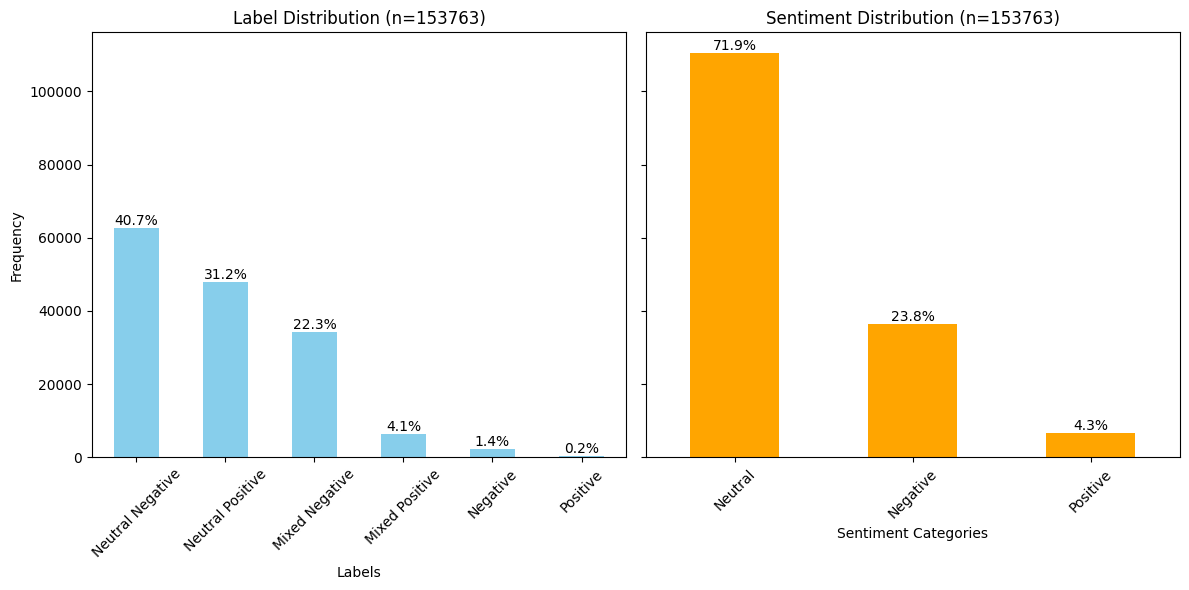

In [12]:
def add_percentage(ax, counts):
    total = counts.sum()
    for p in ax.patches:
        percentage = f"{(p.get_height() / total) * 100:.1f}%"
        ax.annotate(percentage,  (p.get_x() + p.get_width() / 2, p.get_height()), 
                    ha='center', va='bottom', fontsize=10, color='black')

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
df_labels.plot(kind='bar', ax=axes[0], color = 'skyblue')
axes[0].set_title('Label Distribution (n=153763)')
axes[0].set_xlabel('Labels')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=45)
add_percentage(axes[0], df_labels)

df_sentiment.plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Sentiment Distribution (n=153763)')
axes[1].set_xlabel('Sentiment Categories')
axes[1].tick_params(axis='x', rotation=45)
add_percentage(axes[1], df_sentiment)

plt.tight_layout()
plt.savefig('./Figures/Sentiment_Analysis/Heuristic/Sentiment_distribution.png', dpi=300)
plt.show()